In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
df = pd.read_excel(r"C:\Somayeh\2\Capstone\Assignments\Group\Clean Dataset.xlsx")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 4 columns):
 #   Column                                                                                                                                  Non-Null Count  Dtype
---  ------                                                                                                                                  --------------  -----
 0   7. When you think about your organization’s current performance levels, what percentage is fueled by sustainable energy vs exhaustion?  107 non-null    str  
 1   8. How confident are you that your top leaders could maintain their current pace for another 12 months without decline?                 107 non-null    str  
 2   9. Do you currently track any indicators of human energy or burnout risk?                                                               107 non-null    str  
 3   11. What percentage of strategic errors or delays last year were caused by leader fatig

In [ ]:
# Clean only string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.replace('\xa0', '', regex=False)  # remove hidden space
    df[col] = df[col].str.strip()  # remove leading/trailing spaces

C:\Users\gajet\AppData\Local\Temp\ipykernel_21148\449214996.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [ ]:
df.dtypes

7. When you think about your organization’s current performance levels, what percentage is fueled by sustainable energy vs exhaustion?    str
8. How confident are you that your top leaders could maintain their current pace for another 12 months without decline?                   str
9. Do you currently track any indicators of human energy or burnout risk?                                                                 str
11. What percentage of strategic errors or delays last year were caused by leader fatigue or overwhelm?                                   str
dtype: object

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

def analyze_column(df, column_name):
    print(f"\n{'='*50}")
    print(f"📊 Analysis for: {column_name}")
    print(f"{'='*50}\n")
    
    # Count
    count = df[column_name].value_counts(dropna=False)
    
    # Percentage
    percentage = df[column_name].value_counts(normalize=True, dropna=False) * 100
    
    # Mode
    mode = df[column_name].mode()
    
    # Combine
    summary = pd.DataFrame({
        "Count": count,
        "Percentage (%)": percentage.round(2)
    })
    
    print(summary.to_string())   # 👈 forces full display
    print("\nMode:", mode.tolist())
    
    return summary

df.columns = [
    "Q7_energy",
    "Q8_leadership_confidence",
    "Q9_tracking",
    "Q11_fatigue_impact"
]
q7 = analyze_column(df, "Q7_energy")
q8 = analyze_column(df, "Q8_leadership_confidence")
q9 = analyze_column(df, "Q9_tracking")
q11 = analyze_column(df, "Q11_fatigue_impact")


📊 Analysis for: Q7_energy

                                  Count  Percentage (%)
Q7_energy                                              
Not sure — we don’t measure this     94           87.85
60% sustainable / 40% exhaustion      6            5.61
40% sustainable / 60% exhaustion      6            5.61
20% sustainable / 80% exhaustion      1            0.93

Mode: ['Not sure — we don’t measure this']

📊 Analysis for: Q8_leadership_confidence

                                               Count  Percentage (%)
Q8_leadership_confidence                                            
Somewhat confident                                48           44.86
Unsure                                            22           20.56
Not confident                                     18           16.82
Very confident                                    15           14.02
Highly concerned — burnout is already present      4            3.74

Mode: ['Somewhat confident']

📊 Analysis for: Q9_tracking

      

In [ ]:
analyze_column(df, "Q9_tracking")
analyze_column(df, "Q11_fatigue_impact")


📊 Analysis for: Q9_tracking

                      Count  Percentage (%)
Q9_tracking                                
No                       93           86.92
Not yet — exploring       9            8.41
Unsure                    3            2.80
Yes — but informally      2            1.87

Mode: ['No']

📊 Analysis for: Q11_fatigue_impact

                    Count  Percentage (%)
Q11_fatigue_impact                       
Not tracked           106           99.07
25–50%                  1            0.93

Mode: ['Not tracked']


,Count,Percentage (%)
Q11_fatigue_impact,,
Not tracked,106,99.07
25–50%,1,0.93


C:\Users\gajet\AppData\Local\Temp\ipykernel_21148\129653217.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


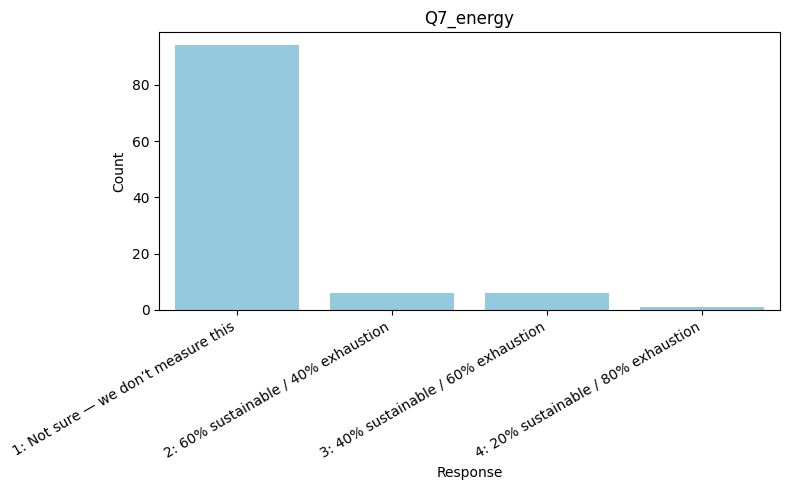

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

col1 = df.iloc[:,0]

df["Q7_code"], labels = pd.factorize(col1)
df["Q7_code"] = df["Q7_code"] + 1

plt.figure(figsize=(8,5))
ax = sns.countplot(x=df["Q7_code"], color="skyblue")

plt.title(df.columns[0])
plt.xlabel("Response")
plt.ylabel("Count")

ax.set_xticklabels([
    f"{i+1}: {label}" for i, label in enumerate(labels)
], rotation=30, ha="right")

plt.tight_layout()
plt.show()

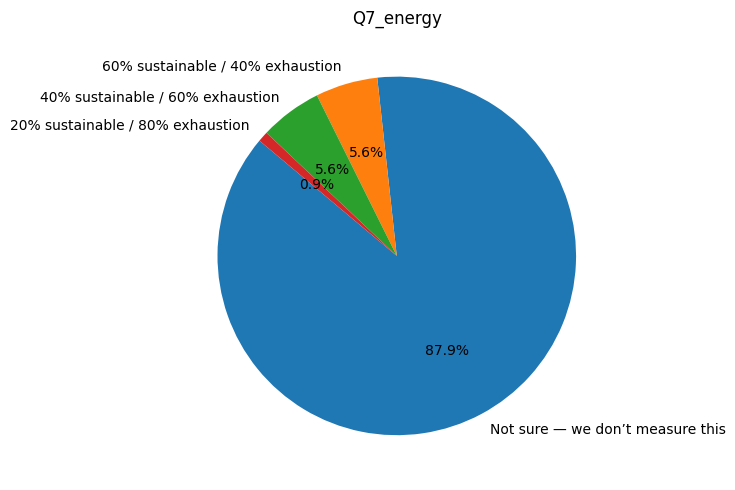

In [ ]:
import matplotlib.pyplot as plt

col1 = df.iloc[:, 0]

# Get counts
counts = col1.value_counts()

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title(df.columns[0])
plt.tight_layout()
plt.show()

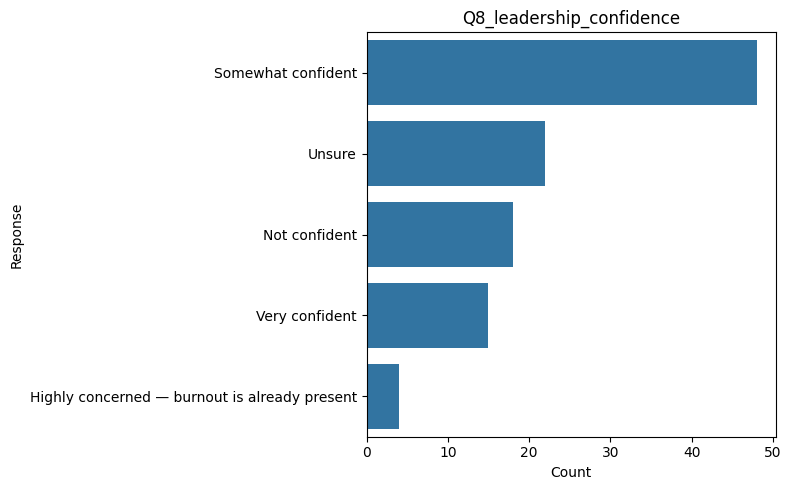

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

col2 = df.iloc[:,1]

plt.figure(figsize=(8,5))
sns.countplot(
    y=col2,
    order=col2.value_counts().index
)
plt.title(df.columns[1])
plt.xlabel("Count")
plt.ylabel("Response")
plt.tight_layout()
plt.show()

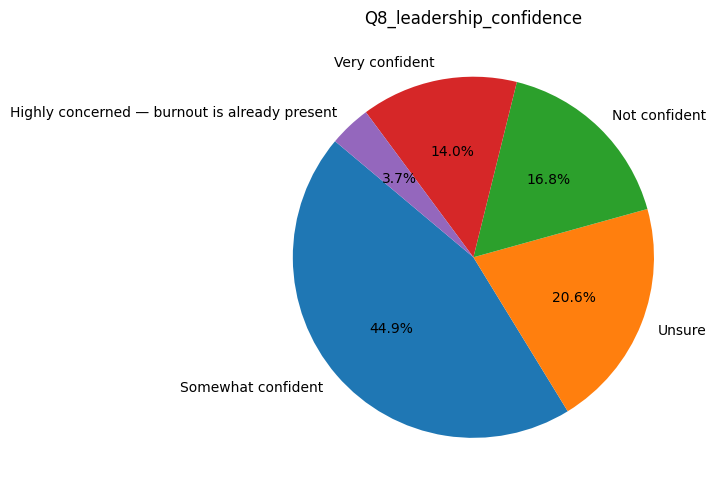

In [ ]:
import matplotlib.pyplot as plt

col2 = df.iloc[:, 1]

# Get counts
counts = col2.value_counts()

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title(df.columns[1])
plt.tight_layout()
plt.show()

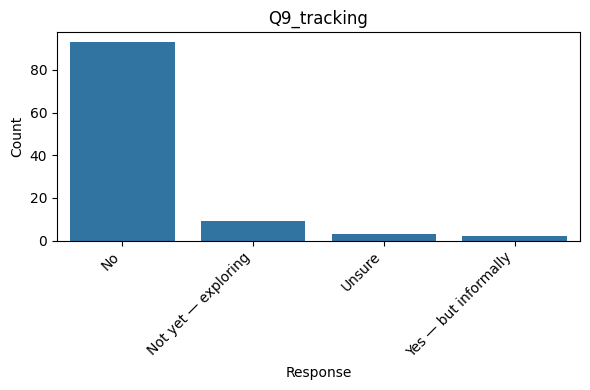

In [ ]:
col3 = df.iloc[:,2]

plt.figure(figsize=(6,4))
sns.countplot(
    x=col3,
    order=col3.value_counts().index
)
plt.title(df.columns[2])
plt.xlabel("Response")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

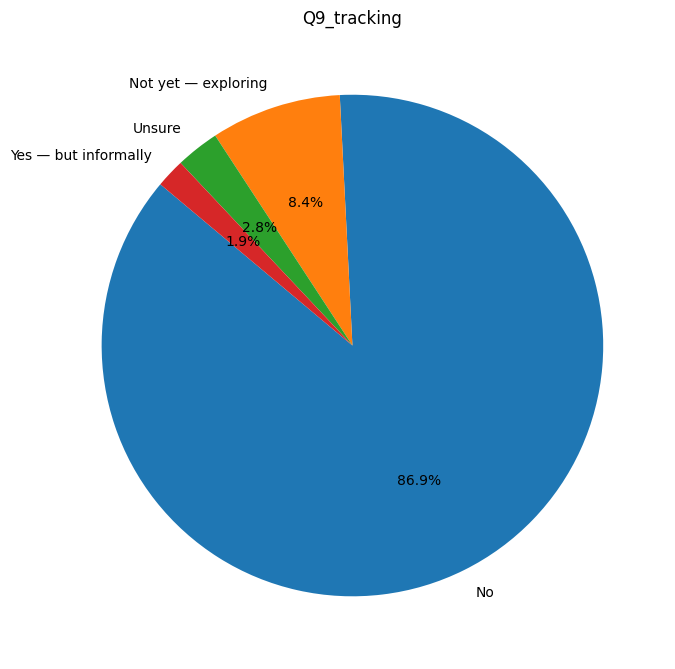

In [ ]:
import matplotlib.pyplot as plt

col3 = df.iloc[:, 2]

# Get counts
counts = col3.value_counts()

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title(df.columns[2])
plt.tight_layout()
plt.show()

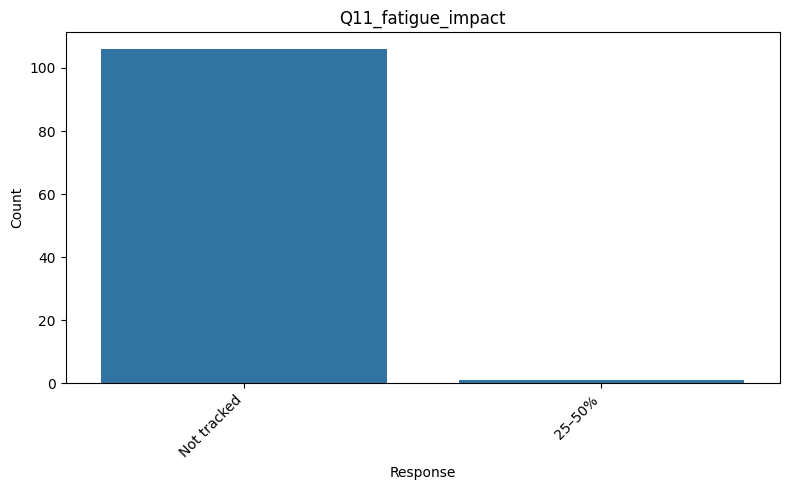

In [ ]:
col4 = df.iloc[:,3]

plt.figure(figsize=(8,5))
sns.countplot(
    x=col4,
    order=col4.value_counts().index
)
plt.title(df.columns[3])
plt.xlabel("Response")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

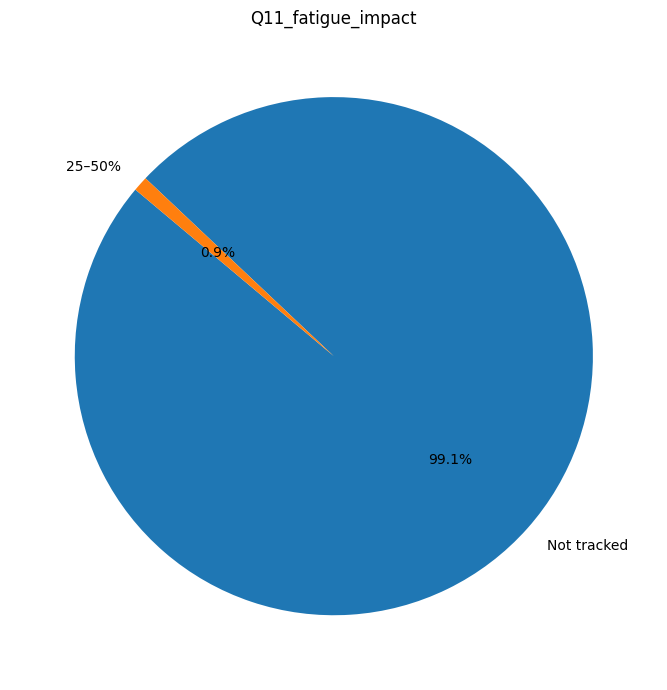

In [ ]:
import matplotlib.pyplot as plt

col14 = df.iloc[:, 3]

# Get counts
counts = col4.value_counts()

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title(df.columns[3])
plt.tight_layout()
plt.show()

In [ ]:
# Map responses to sustainable % and exhaustion %
ser_map = {
    "60% sustainable / 40% exhaustion": 60,
    "40% sustainable / 60% exhaustion": 40,
    "20% sustainable / 80% exhaustion": 20,
    "Not sure — we don’t measure this": None  # treat as missing
}

df["Sustainable_pct"] = df["Q7_energy"].map(ser_map)

# Calculate SER (exclude missing)
ser = df["Sustainable_pct"].dropna().mean()
print(f"Sustainable Energy Ratio (SER): {ser:.2f}%")

# Interpretation
if ser >= 80:
    interpretation_ser = "Healthy, sustainable performance"
elif ser >= 60:
    interpretation_ser = "Moderate risk"
else:
    interpretation_ser = "Burnout risk zone"
print("SER interpretation:", interpretation_ser)

Sustainable Energy Ratio (SER): 47.69%
SER interpretation: Burnout risk zone


In [ ]:
lsci_map = {
    "Highly concerned — burnout is already present": 1,
    "Not confident": 2,
    "Unsure": 3,
    "Somewhat confident": 4,
    "Very confident": 5
}

df["Confidence_score"] = df["Q8_leadership_confidence"].map(lsci_map)

# Calculate LSCI
lsci = df["Confidence_score"].mean()
print(f"Leadership Sustainability Confidence Index (LSCI): {lsci:.2f}")

# Interpretation
if lsci >= 4.0:
    interpretation_lsci = "Strong confidence"
elif lsci >= 3.0:
    interpretation_lsci = "Watch zone"
else:
    interpretation_lsci = "High risk of leadership burnout"
print("LSCI interpretation:", interpretation_lsci)

Leadership Sustainability Confidence Index (LSCI): 3.49
LSCI interpretation: Watch zone


In [ ]:
etmi_map = {
    "No": 0,
    "Not yet — exploring": 1,
    "Unsure": 2,
    "Yes — but informally": 3
}

df["Tracking_score"] = df["Q9_tracking"].map(etmi_map)

# Average ETMI
etmi = df["Tracking_score"].mean()
print(f"Energy Tracking Maturity Index (ETMI): {etmi:.2f}")

# Interpretation
if etmi <= 1:
    interpretation_etmi = "Reactive organization"
elif etmi == 2:
    interpretation_etmi = "Developing"
else:
    interpretation_etmi = "Mature / proactive"
print("ETMI interpretation:", interpretation_etmi)

Energy Tracking Maturity Index (ETMI): 0.20
ETMI interpretation: Reactive organization


In [ ]:
def fatigue_pct(x):
    if x == "Not tracked":
        return 0
    elif x == "25–50%":
        return 0.375  # midpoint 37.5%
    else:
        return None

df["Fatigue_pct"] = df["Q11_fatigue_impact"].apply(fatigue_pct)

# FIR = average fatigue impact
fir = df["Fatigue_pct"].mean() * 100
print(f"Fatigue Impact Rate (FIR): {fir:.2f}%")

# Interpretation
if fir < 10:
    interpretation_fir = "Healthy"
elif fir <= 25:
    interpretation_fir = "Moderate concern"
else:
    interpretation_fir = "Critical issue"
print("FIR interpretation:", interpretation_fir)

Fatigue Impact Rate (FIR): 0.35%
FIR interpretation: Healthy
